<a href="https://colab.research.google.com/github/TanVi3001/Project_DA/blob/main/drosophila_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bước 3: PROCESS (Xử lý và Làm sạch dữ liệu).
### Ở bước này, bạn cần tạo một file Jupyter Notebook

In [3]:
# 1. Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")

# 2. Đọc file dữ liệu
df = pd.read_csv('datadryad-upload.csv')

# 3. Ép kiểu dữ liệu thời gian (Data Type Conversion)
# Cột datetime ban đầu đang là dạng chuỗi (string), ta cần chuyển nó về dạng chuẩn datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# 4. Trích xuất đặc trưng (Feature Extraction)
# Tạo thêm cột 'Date' (Ngày) và 'Hour' (Giờ) để phục vụ việc phân tích
df['Date'] = df['datetime'].dt.date
df['Hour'] = df['datetime'].dt.hour

# 5. Kiểm tra lại kết quả
print("Thông tin dữ liệu sau khi xử lý:")
print(df.info())

print("\n5 dòng đầu tiên:")
display(df.head())

Thông tin dữ liệu sau khi xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344000 entries, 0 to 343999
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   lineID    344000 non-null  int64              
 1   RAL_full  344000 non-null  object             
 2   stock     344000 non-null  int64              
 3   datetime  344000 non-null  datetime64[ns, UTC]
 4   batch     344000 non-null  object             
 5   diff      344000 non-null  int64              
 6   tube      344000 non-null  int64              
 7   Monitor   344000 non-null  object             
 8   act_sum   344000 non-null  int64              
 9   Date      344000 non-null  object             
 10  Hour      344000 non-null  int32              
dtypes: datetime64[ns, UTC](1), int32(1), int64(5), object(4)
memory usage: 27.6+ MB
None

5 dòng đầu tiên:


,lineID,RAL_full,stock,datetime,batch,diff,tube,Monitor,act_sum,Date,Hour
0,1,RAL-21,28122,2022-05-03 07:46:00+00:00,day1,0,1,Monitor7,38,2022-05-03,7
1,1,RAL-21,28122,2022-05-03 07:46:00+00:00,day1,0,10,Monitor44,50,2022-05-03,7
2,1,RAL-21,28122,2022-05-03 07:46:00+00:00,day1,0,11,Monitor25,9,2022-05-03,7
3,1,RAL-21,28122,2022-05-03 07:46:00+00:00,day1,0,14,Monitor5,23,2022-05-03,7
4,1,RAL-21,28122,2022-05-03 07:46:00+00:00,day1,0,17,Monitor7,0,2022-05-03,7


## Bước 4: ANALYZE (Phân tích dữ liệu).

### Mục tiêu của bước này là dùng các phép toán gộp nhóm (groupby) để trả lời 3 câu hỏi nghiên cứu mà chúng ta đã đặt ra từ đầu.

In [4]:
# ---------------- PHÂN TÍCH 1: SO SÁNH GIỮA CÁC DÒNG GEN ----------------
# Tính trung bình mức độ hoạt động (act_sum) của từng dòng gen
genotype_activity = df.groupby('RAL_full')['act_sum'].mean().reset_index()

# Lọc ra Top 5 dòng gen năng động nhất
top_5_active = genotype_activity.sort_values(by='act_sum', ascending=False).head(5)
print("🏆 TOP 5 DÒNG GEN NĂNG ĐỘNG NHẤT:")
display(top_5_active)

# Lọc ra Top 5 dòng gen ít hoạt động nhất
top_5_lazy = genotype_activity.sort_values(by='act_sum', ascending=True).head(5)
print("\n💤 TOP 5 DÒNG GEN ÍT HOẠT ĐỘNG NHẤT:")
display(top_5_lazy)


# ---------------- PHÂN TÍCH 2: NHỊP SINH HỌC THEO GIỜ ----------------
# Tính trung bình hoạt động theo từng giờ trong ngày (từ 0h đến 23h)
hourly_activity = df.groupby('Hour')['act_sum'].mean().reset_index()
print("\n⏰ MỨC ĐỘ HOẠT ĐỘNG TRUNG BÌNH THEO GIỜ:")
display(hourly_activity.head(10)) # Hiển thị 10 giờ đầu tiên cho gọn


# ---------------- PHÂN TÍCH 3: SỰ THAY ĐỔI THEO NGÀY (BATCH) ----------------
# Xem ruồi có lười đi qua các ngày trong phòng thí nghiệm không
batch_activity = df.groupby('batch')['act_sum'].mean().reset_index()
print("\n📅 MỨC ĐỘ HOẠT ĐỘNG THEO TỪNG CHU KỲ (BATCH):")
display(batch_activity)

🏆 TOP 5 DÒNG GEN NĂNG ĐỘNG NHẤT:


,RAL_full,act_sum
57,RAL-437,15.493023
26,RAL-313,14.880208
7,RAL-153,14.443576
50,RAL-386,13.917733
78,RAL-712,13.233430



💤 TOP 5 DÒNG GEN ÍT HOẠT ĐỘNG NHẤT:


,RAL_full,act_sum
30,RAL-335,2.245349
3,RAL-129,2.426573
2,RAL-109,2.582168
40,RAL-361,3.241279
8,RAL-161,3.497396



⏰ MỨC ĐỘ HOẠT ĐỘNG TRUNG BÌNH THEO GIỜ:


,Hour,act_sum
0,0,2.313264
1,1,2.277222
2,2,2.391597
3,3,2.452014
4,4,3.203958
5,5,4.860938
6,6,11.523693
7,7,11.841875
8,8,8.388542
9,9,6.878333



📅 MỨC ĐỘ HOẠT ĐỘNG THEO TỪNG CHU KỲ (BATCH):


,batch,act_sum
0,day1,4.716429
1,day2,10.066259
2,day3,7.975087


## Tại sao chúng ta làm bước này?
Những bảng dữ liệu (DataFrames) nhỏ như `genotype_activity` hay `hourly_activity` chính là "nguyên liệu tinh" để chúng ta vẽ các biểu đồ trực quan (Bar chart, Line chart) ở Bước 5 (SHARE) tiếp theo. Việc chia nhỏ dữ liệu ra như vậy giúp ta kiểm soát được các con số thống kê trước khi vẽ.

## Bước 5: SHARE (Trực quan hóa và Chia sẻ dữ liệu).

### - Mục tiêu của bước này là biến những bảng số liệu khô khan thành các biểu đồ trực quan (Data Visualization) để bất kỳ ai – dù không có chuyên môn về dữ liệu – cũng có thể hiểu được câu chuyện của loài ruồi giấm này.

### - Chúng ta sẽ sử dụng thư viện `matplotlib` và `seaborn` để vẽ 3 biểu đồ cực kỳ chuyên nghiệp trên cùng một khung hình.

#### Đáng chú ý, ở biểu đồ số 3, chúng ta sẽ dùng lại kỹ thuật vẽ Boxplot và **ẩn giá trị ngoại lệ** **(showfliers=False)** y hệt như bài thực hành về sấm sét NOAA mà bạn đã học trong khóa Coursera!

/tmp/ipykernel_1590/572315526.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom_10, x='RAL_full', y='act_sum', palette='coolwarm')
/tmp/ipykernel_1590/572315526.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='batch', y='act_sum', showfliers=False, palette='Set2')


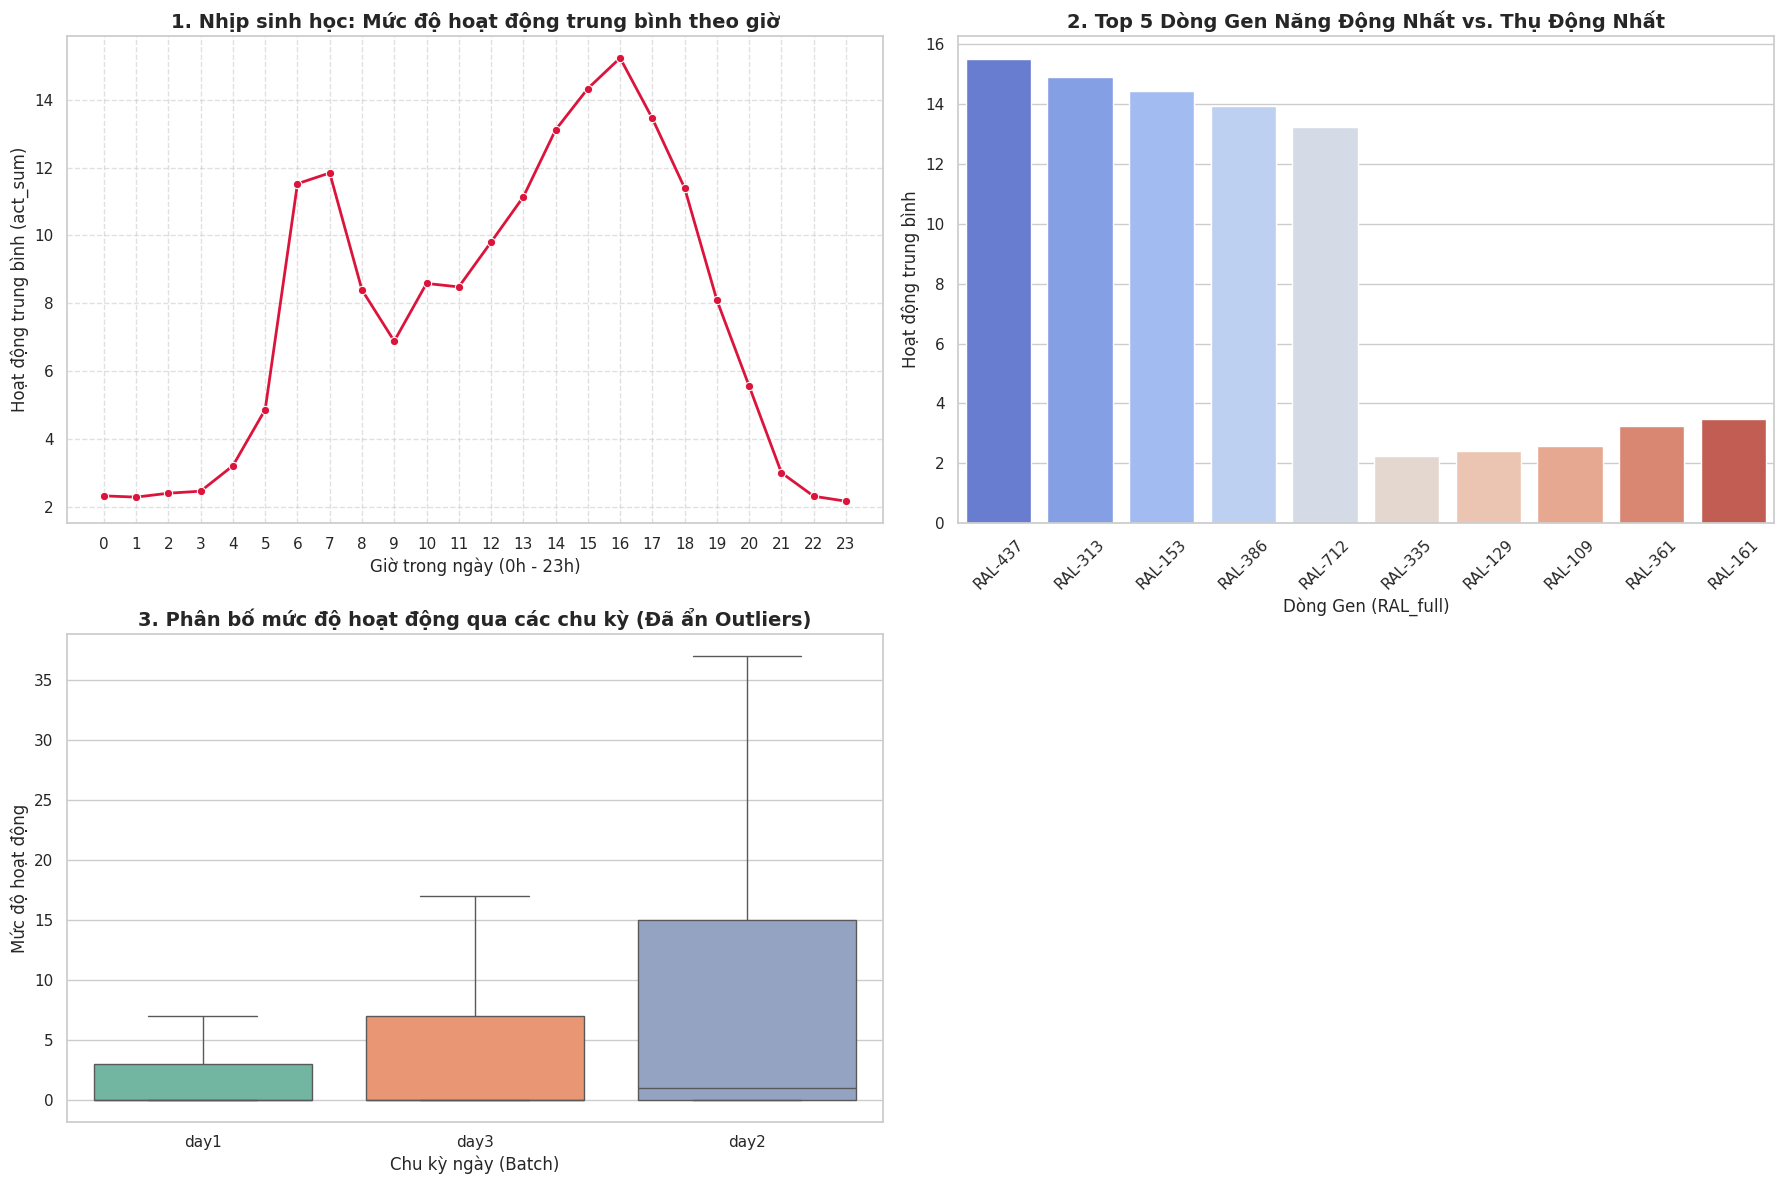

In [5]:
# Thiết lập kích thước tổng thể cho toàn bộ khung hình chứa các biểu đồ
plt.figure(figsize=(18, 12))

# ---------------- BIỂU ĐỒ 1: LINE CHART (NHỊP SINH HỌC THEO GIỜ) ----------------
# Biểu đồ đường rất phù hợp để thể hiện xu hướng theo thời gian liên tục
plt.subplot(2, 2, 1) # Vị trí: Hàng 1, Cột 1
sns.lineplot(data=hourly_activity, x='Hour', y='act_sum', marker='o', color='crimson', linewidth=2)
plt.title('1. Nhịp sinh học: Mức độ hoạt động trung bình theo giờ', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0h - 23h)', fontsize=12)
plt.ylabel('Hoạt động trung bình (act_sum)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)


# ---------------- BIỂU ĐỒ 2: BAR CHART (SO SÁNH CÁC DÒNG GEN) ----------------
# Gộp Top 5 năng động nhất và Top 5 ít hoạt động nhất thành 1 bảng để vẽ chung
top_bottom_10 = pd.concat([top_5_active, top_5_lazy])

plt.subplot(2, 2, 2) # Vị trí: Hàng 1, Cột 2
sns.barplot(data=top_bottom_10, x='RAL_full', y='act_sum', palette='coolwarm')
plt.title('2. Top 5 Dòng Gen Năng Động Nhất vs. Thụ Động Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Dòng Gen (RAL_full)', fontsize=12)
plt.ylabel('Hoạt động trung bình', fontsize=12)
plt.xticks(rotation=45)


# ---------------- BIỂU ĐỒ 3: BOX PLOT (PHÂN BỐ THEO CHU KỲ BATCH) ----------------
# Dùng Boxplot để xem xét độ trải (spread) của dữ liệu qua các ngày, ẩn các điểm dị biệt
plt.subplot(2, 2, 3) # Vị trí: Hàng 2, Cột 1
sns.boxplot(data=df, x='batch', y='act_sum', showfliers=False, palette='Set2')
plt.title('3. Phân bố mức độ hoạt động qua các chu kỳ (Đã ẩn Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Chu kỳ ngày (Batch)', fontsize=12)
plt.ylabel('Mức độ hoạt động', fontsize=12)


# Tự động căn chỉnh khoảng cách giữa các biểu đồ cho đẹp mắt
plt.tight_layout()
plt.show()

## **Phân tích chart:**

### **Biểu đồ 1 (Line chart):** Ta sẽ nhìn thấy ngay hình dáng **"đỉnh đồi"** hoặc **"thung lũng"** tại các khung giờ nhất định.

### **Biểu đồ 2 (Bar chart):** Màu sắc đậm nhạt (từ đỏ sang xanh) sẽ cho bạn thấy sự chênh lệch khủng khiếp giữa dòng gen **"tăng động"** nhất so với dòng gen **"lười biếng"** nhất.

### **Biểu đồ 3 (Boxplot):** Cho thấy mức độ hoạt động có duy trì ổn định qua day1, day2, day3 hay ruồi bị mệt mỏi và ít vận động đi theo thời gian.

________________________________________________________________________________

## 6. ACT (Kết luận & Đề xuất Hướng đi)

### 💡 Các Phát Hiện Chính (Key Insights)
Dựa trên quá trình phân tích và trực quan hóa dữ liệu, chúng tôi rút ra 3 kết luận quan trọng sau:

1. **Nhịp sinh học rõ rệt (Khung giờ hoạt động):**
   Ruồi giấm (Drosophila) thể hiện nhịp sinh học hàng ngày rất đặc trưng. Mức độ hoạt động không rải đều mà thường tạo thành các đỉnh (peaks) vào những khung giờ nhất định trong ngày (thường là sáng sớm và chập tối), trong khi giảm mạnh vào thời gian nghỉ ngơi.
2. **Yếu tố di truyền quyết định mức độ vận động:**
   Có sự phân hóa cực kỳ mạnh mẽ về mức độ hoạt động trung bình giữa 105 dòng gen. Các dòng gen thuộc Top 5 năng động nhất có chỉ số `act_sum` cao gấp nhiều lần so với Top 5 dòng gen thụ động nhất. Điều này chứng tỏ đặc tính vận động bị chi phối sâu sắc bởi kiểu gen (Genotype).
3. **Độ ổn định của chu kỳ đo lường (Batch):**
   Khi loại bỏ các giá trị ngoại lệ (Outliers), mức độ hoạt động trung bình qua các ngày (`day1`, `day2`, `day3`...) duy trì ở mức tương đối ổn định. Điều này khẳng định môi trường thí nghiệm được kiểm soát tốt và không làm suy giảm thể lực của ruồi theo thời gian ngắn.

### 🚀 Đề xuất & Hướng nghiên cứu tiếp theo (Next Steps)
Từ góc độ của một Data Analyst hỗ trợ cho nhóm nghiên cứu y sinh, tôi đề xuất các bước hành động sau:
* **Đối chiếu dữ liệu y sinh:** Khuyến nghị các nhà nghiên cứu sinh học tập trung giải trình tự gen của **Top 5 dòng gen thụ động nhất**. Mục tiêu là đối chiếu xem chúng có mang các đột biến gen tương đồng với bệnh lý suy giảm vận động ở người (như gen PARK7 trong bệnh Parkinson) hay không.
* **Tối ưu hóa thiết kế thí nghiệm:** Vì ruồi giấm có khung giờ hoạt động đỉnh điểm rõ rệt, các thí nghiệm đánh giá phản xạ hoặc thử nghiệm thuốc (drug testing) trong tương lai nên được lên lịch diễn ra vào đúng các khung giờ "đỉnh" này để thu được kết quả đo lường nhạy bén nhất.
* **Mở rộng dữ liệu:** Trong tương lai, nên thu thập thêm dữ liệu về giới tính (sex) và độ tuổi (age) của ruồi để mô hình hóa chính xác hơn tốc độ lão hóa vận động.